# FM Performance vs MSE AE Latent Dimensionality

evaluates flow matching models trained in MSE AE latent space at different
dimensions (16-1024). overlays AE theoretical reconstruction limits and
compares with the PCA FM sweep results.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite

DIMS = [16, 32, 64, 128, 256, 512, 1024]
RUNS_ROOT = Path("artifacts/runs")

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc", "mmd"]
group_columns = ["cell_type", "product_dose"]
reductions = ["unweighted_mean"]

metric_lower_is_better = {
    "mean_gene_w1": True,
    "w2_squared": True,
    "cosine_log_fc": False,
    "mmd": True,
}
metric_direction = {
    "mean_gene_w1": "\u2193",
    "w2_squared": "\u2193",
    "cosine_log_fc": "\u2191",
    "mmd": "\u2193",
}

In [2]:
# find available FM AE MSE experiments with predictions
ae_experiments = []
ae_dims = []
for dim in DIMS:
    exp_name = f"sciplex_fm_deg_ae_mse_d{dim}"
    exp_dir = RUNS_ROOT / exp_name
    if not exp_dir.is_dir():
        print(f"SKIP d={dim}: no run directory")
        continue
    subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
    if not subdirs:
        print(f"SKIP d={dim}: no run subdirectory")
        continue
    latest = subdirs[-1]
    if not (latest / "predictions" / "held_out" / "predictions.h5ad").exists():
        print(f"SKIP d={dim}: no predictions")
        continue
    ae_experiments.append(exp_name)
    ae_dims.append(dim)
    print(f"d={dim}: ready")

print(f"\n{len(ae_experiments)}/{len(DIMS)} AE models available")
if not ae_experiments:
    raise RuntimeError("no FM AE MSE models available -- run scripts/check_fm_ae_mse_sweep.py --train first")

d=16: ready
SKIP d=32: no run directory
SKIP d=64: no run directory
SKIP d=128: no run directory
SKIP d=256: no run directory
SKIP d=512: no run directory
SKIP d=1024: no run directory

1/7 AE models available


In [3]:
# evaluate FM AE MSE models (cached by prediction fingerprint)
import hashlib

CACHE_DIR = Path("artifacts/fm_ae_mse_sweep_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _predictions_fingerprint(experiments: list[str]) -> str:
    parts = []
    for exp in sorted(experiments):
        exp_dir = RUNS_ROOT / exp
        subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subdirs:
            continue
        pred_path = subdirs[-1] / "predictions" / "held_out" / "predictions.h5ad"
        if pred_path.exists():
            parts.append(f"{pred_path}:{pred_path.stat().st_mtime}")
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


cache_key = _predictions_fingerprint(ae_experiments)
per_group_cache = CACHE_DIR / f"per_group_{cache_key}.parquet"

if per_group_cache.exists():
    ae_per_group = pd.read_parquet(per_group_cache)
    print(f"loaded cached results ({cache_key})")
    print(f"per group rows: {len(ae_per_group)}")
else:
    result = run_benchmark_suite(
        {
            "experiments": ae_experiments,
            "metrics": ["mean_gene_w1", "w2_squared", "cosine_log_fc"],
            "group_columns": group_columns,
            "reductions": reductions,
        }
    )

    result_mmd = run_benchmark_suite(
        {
            "experiments": ae_experiments,
            "metrics": ["mmd"],
            "group_columns": group_columns,
            "reductions": reductions,
            "metric_spaces": [
                {"name": "train_pca_50", "kind": "train_pca", "pca_n_components": 50},
            ],
        }
    )

    ae_per_group = pd.concat([result["per_group_metrics"], result_mmd["per_group_metrics"]], ignore_index=True)

    ae_per_group.to_parquet(per_group_cache)
    print(f"saved results to cache ({cache_key})")
    print(f"per group rows: {len(ae_per_group)}")

/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

saved results to cache (a8ce712d3bb9)
per group rows: 1500


In [4]:
# extract per-dim AE FM results
ae_rows = []
for dim, exp_name in zip(ae_dims, ae_experiments):
    for metric in metrics:
        subset = ae_per_group[(ae_per_group["model_name"] == exp_name) & (ae_per_group["metric_base"] == metric)]
        if subset.empty:
            subset = ae_per_group[(ae_per_group["model_name"] == exp_name) & (ae_per_group["metric"] == metric)]
        if subset.empty:
            continue
        ae_rows.append(
            {
                "dim": dim,
                "metric": metric,
                "mean": subset["value"].mean(),
                "std": subset["value"].std(),
                "n_groups": len(subset),
            }
        )

ae_df = pd.DataFrame(ae_rows)

if not ae_df.empty:
    display_pivot = ae_df.pivot_table(index="dim", columns="metric", values="mean").round(4)
    display(display_pivot)

metric,cosine_log_fc,mean_gene_w1,mmd,w2_squared
dim,,,,
16,0.1525,0.2263,0.0495,2164.6515


In [5]:
# load PCA FM sweep results for comparison
pca_cache_dir = Path("artifacts/fm_pca_sweep_cache")
pca_df = None
if pca_cache_dir.exists():
    pca_caches = sorted(pca_cache_dir.glob("per_group_*.parquet"))
    if pca_caches:
        pca_per_group = pd.read_parquet(pca_caches[-1])
        pca_rows = []
        for dim in DIMS:
            exp_name = f"sciplex_fm_deg_pca_d{dim}"
            for metric in metrics:
                subset = pca_per_group[
                    (pca_per_group["model_name"] == exp_name)
                    & ((pca_per_group["metric_base"] == metric) | (pca_per_group["metric"] == metric))
                ]
                if subset.empty:
                    continue
                pca_rows.append(
                    {
                        "dim": dim,
                        "metric": metric,
                        "mean": subset["value"].mean(),
                        "std": subset["value"].std(),
                    }
                )
        pca_df = pd.DataFrame(pca_rows)
        print(f"loaded PCA FM results ({len(pca_df)} rows)")
    else:
        print("no PCA FM sweep cache found")
else:
    print("no PCA FM sweep cache found -- run view_fm_pca_sweep.ipynb first for comparison")

loaded PCA FM results (16 rows)


In [6]:
# load theoretical limits for both PCA and MSE AE
theo_pca_df = None
theo_ae_df = None

pca_theo_cache = Path("artifacts/theoretical_limits_cache/pca_results.json")
if pca_theo_cache.exists():
    theo_raw = json.loads(pca_theo_cache.read_text())
    theo_all = pd.DataFrame(theo_raw)
    agg_dict = {
        "cosine_logfc_mean": ("cosine_logfc", "mean"),
        "w2_mean": ("w2", "mean"),
    }
    if "mean_gene_w1" in theo_all.columns:
        agg_dict["mean_gene_w1_mean"] = ("mean_gene_w1", "mean")
    if "mmd_pca50" in theo_all.columns:
        agg_dict["mmd_pca50_mean"] = ("mmd_pca50", "mean")
    theo_pca_df = theo_all.groupby("latent_dim").agg(**agg_dict).reset_index().rename(columns={"latent_dim": "dim"})
    theo_pca_df["w2_squared_mean"] = theo_pca_df["w2_mean"] ** 2
    print(f"PCA theoretical limits: {sorted(theo_pca_df['dim'].unique())}")

ae_theo_cache = Path("artifacts/theoretical_limits_cache/ae_results.json")
if ae_theo_cache.exists():
    ae_theo_raw = json.loads(ae_theo_cache.read_text())
    ae_theo_all = pd.DataFrame(ae_theo_raw)
    ae_theo_mse = ae_theo_all[ae_theo_all["method"] == "MSE AE"]
    if not ae_theo_mse.empty:
        ae_agg = {
            "cosine_logfc_mean": ("cosine_logfc", "mean"),
            "w2_mean": ("w2", "mean"),
        }
        if "mean_gene_w1" in ae_theo_mse.columns:
            ae_agg["mean_gene_w1_mean"] = ("mean_gene_w1", "mean")
        theo_ae_df = ae_theo_mse.groupby("latent_dim").agg(**ae_agg).reset_index().rename(columns={"latent_dim": "dim"})
        theo_ae_df["w2_squared_mean"] = theo_ae_df["w2_mean"] ** 2
        print(f"MSE AE theoretical limits: {sorted(theo_ae_df['dim'].unique())}")
    else:
        print("no MSE AE entries in AE theoretical limits cache")
else:
    print("no AE theoretical limit cache found")

PCA theoretical limits: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2000), np.int64(5000), np.int64(6396)]
MSE AE theoretical limits: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024)]


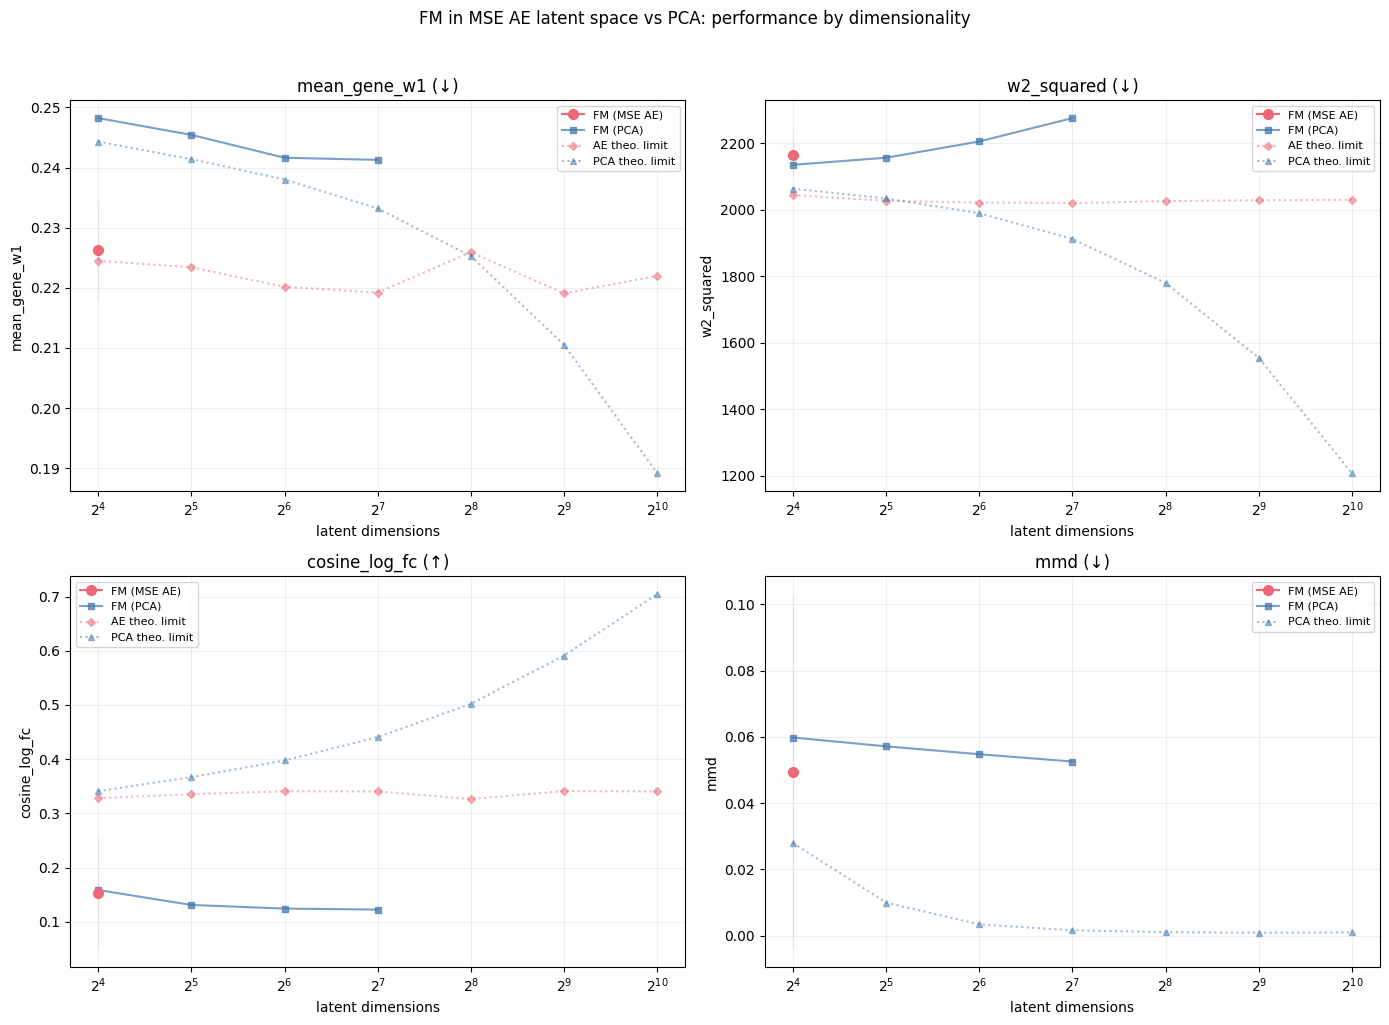

In [ ]:
# plot FM AE MSE vs FM PCA performance with theoretical limits
from adjustText import adjust_text

plot_metrics = [m for m in metrics if m in ae_df["metric"].unique()]
n_metrics = len(plot_metrics)
ncols = 2
nrows = (n_metrics + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

theo_metric_map = {
    "cosine_log_fc": "cosine_logfc_mean",
    "w2_squared": "w2_squared_mean",
    "mean_gene_w1": "mean_gene_w1_mean",
    "mmd": "mmd_pca50_mean",
}

for ax_idx, metric in enumerate(plot_metrics):
    ax = axes[ax_idx]

    # FM AE MSE performance
    mdf = ae_df[ae_df["metric"] == metric].sort_values("dim")
    ax.plot(
        mdf["dim"],
        mdf["mean"],
        marker="o",
        color="#EE6677",
        label="FM (MSE AE)",
        markersize=7,
        zorder=3,
    )
    ax.fill_between(
        mdf["dim"],
        mdf["mean"] - mdf["std"],
        mdf["mean"] + mdf["std"],
        alpha=0.15,
        color="#EE6677",
    )

    # FM PCA performance for comparison
    if pca_df is not None:
        pdf = pca_df[pca_df["metric"] == metric].sort_values("dim")
        if not pdf.empty:
            ax.plot(
                pdf["dim"],
                pdf["mean"],
                marker="s",
                color="#4477AA",
                label="FM (PCA)",
                markersize=5,
                alpha=0.7,
            )

    # MSE AE theoretical limit
    theo_col = theo_metric_map.get(metric)
    if theo_ae_df is not None and theo_col is not None and theo_col in theo_ae_df.columns:
        tdf = theo_ae_df[theo_ae_df["dim"].isin(DIMS)].sort_values("dim")
        if not tdf.empty:
            ax.plot(
                tdf["dim"],
                tdf[theo_col],
                marker="D",
                color="#EE6677",
                linestyle=":",
                label="AE theo. limit",
                markersize=4,
                alpha=0.5,
            )

    # PCA theoretical limit
    if theo_pca_df is not None and theo_col is not None and theo_col in theo_pca_df.columns:
        tdf = theo_pca_df[theo_pca_df["dim"].isin(DIMS)].sort_values("dim")
        if not tdf.empty:
            ax.plot(
                tdf["dim"],
                tdf[theo_col],
                marker="^",
                color="#4477AA",
                linestyle=":",
                label="PCA theo. limit",
                markersize=4,
                alpha=0.5,
            )

    direction = metric_direction.get(metric, "")
    ax.set_xlabel("latent dimensions")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} ({direction})")
    ax.set_xscale("log", base=2)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("FM in MSE AE latent space vs PCA: performance by dimensionality", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# side-by-side comparison table
if pca_df is not None and not ae_df.empty:
    ae_pivot = ae_df.pivot_table(index="dim", columns="metric", values="mean")
    pca_pivot = pca_df.pivot_table(index="dim", columns="metric", values="mean")

    for metric in ["cosine_log_fc", "w2_squared", "mean_gene_w1"]:
        if metric not in ae_pivot.columns or metric not in pca_pivot.columns:
            continue
        combined = pd.DataFrame(
            {
                "FM (MSE AE)": ae_pivot[metric],
                "FM (PCA)": pca_pivot[metric],
            }
        ).dropna(how="all")
        lower = metric_lower_is_better.get(metric, True)
        if lower:
            combined["AE better?"] = combined["FM (MSE AE)"] < combined["FM (PCA)"]
        else:
            combined["AE better?"] = combined["FM (MSE AE)"] > combined["FM (PCA)"]
        direction = metric_direction.get(metric, "")
        print(f"\n{metric} ({direction})")
        display(combined.round(4))


cosine_log_fc (↑)


,FM (MSE AE),FM (PCA),AE better?
dim,,,
16,0.1525,0.1585,False
32,NaN,0.1309,False
64,NaN,0.1242,False
128,NaN,0.1224,False



w2_squared (↓)


,FM (MSE AE),FM (PCA),AE better?
dim,,,
16,2164.6515,2134.9046,False
32,NaN,2156.2584,False
64,NaN,2205.1740,False
128,NaN,2275.3828,False



mean_gene_w1 (↓)


,FM (MSE AE),FM (PCA),AE better?
dim,,,
16,0.2263,0.2482,True
32,NaN,0.2454,False
64,NaN,0.2416,False
128,NaN,0.2413,False
